In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional plotting style for your portfolio
plt.style.use('seaborn-v0_8-darkgrid')

# Load the raw BAF dataset
df = pd.read_csv("../data/Base.csv")

print(f"Dataset Shape: {df.shape[0]:,} rows | {df.shape[1]} columns")

# Separate features by data type to understand what we are dealing with
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nFeature Breakdown:")
print(f" - Numerical columns: {len(num_cols)}")
print(f" - Categorical text columns: {len(cat_cols)}")

# Display the memory usage to ensure we don't crash our pipeline later
memory_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f"\nTotal Memory Footprint: {memory_gb:.2f} GB")

Dataset Shape: 1,000,000 rows | 32 columns

Feature Breakdown:
 - Numerical columns: 27
 - Categorical text columns: 5

Total Memory Footprint: 0.48 GB


In [19]:
unique_counts = df.nunique()

# 1. Zero-Variance Hunt (Columns with exactly 1 unique value)
zero_variance_cols = unique_counts[unique_counts == 1].index.tolist()

if zero_variance_cols:
    print(f"CRITICAL WARNING: Found {len(zero_variance_cols)} column(s) with absolutely zero mathematical variance:")
    for col in zero_variance_cols:
        val = df[col].iloc[0]
        print(f"  --> '{col}' (Every single row = {val})")
        # Drop it immediately from our working dataframe
        df = df.drop(columns=[col])
        print(f"      [ACTION TAKEN] Dropped '{col}' from dataframe.")
else:
    print("Pass: No zero-variance columns found.")

# 2. High Cardinality Check (Text columns with too many unique values)
print("\nCategorical Column Cardinality:")
for col in cat_cols:
    if col in df.columns:
        print(f"  - {col}: {df[col].nunique()} unique categories")
print("Conclusion: Cardinality is low enough (under 10) to safely use Target Encoding later.")

CRITICAL WARNING: Found 1 column(s) with absolutely zero mathematical variance:
  --> 'device_fraud_count' (Every single row = 0)
      [ACTION TAKEN] Dropped 'device_fraud_count' from dataframe.

Categorical Column Cardinality:
  - payment_type: 5 unique categories
  - employment_status: 7 unique categories
  - housing_status: 7 unique categories
  - source: 2 unique categories
  - device_os: 5 unique categories
Conclusion: Cardinality is low enough (under 10) to safely use Target Encoding later.


Columns containing the hidden '-1' placeholder:
  - prev_address_months_count: 712,920 rows (71.29%)
  - bank_months_count: 253,635 rows (25.36%)
  - current_address_months_count: 4,254 rows (0.43%)
  - session_length_in_minutes: 2,015 rows (0.20%)
  - credit_risk_score: 488 rows (0.05%)
  - device_distinct_emails_8w: 359 rows (0.04%)


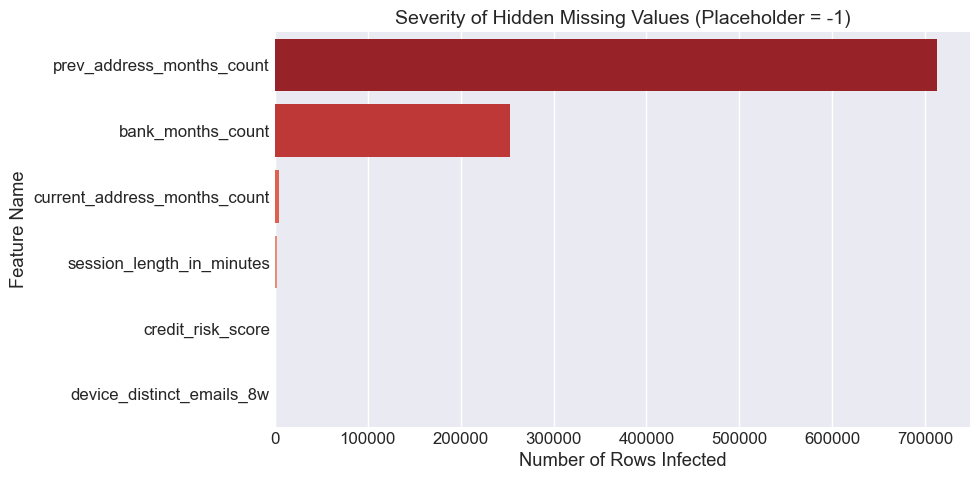


[ARCHITECTURAL NOTE]: We must flag these specific columns with an 'is_missing' boolean during Phase 3.


In [23]:
sentinel_value = -1
# Calculate exactly how many -1 values exist in every column
sentinel_counts = (df == sentinel_value).sum()

# Filter for columns that actually contain the sentinel
infected_cols = sentinel_counts[sentinel_counts > 0].sort_values(ascending=False)

print(f"Columns containing the hidden '{sentinel_value}' placeholder:")
for col, count in infected_cols.items():
    percentage = (count / len(df)) * 100
    print(f"  - {col}: {count:,} rows ({percentage:.2f}%)")

# Visualize the damage 
plt.figure(figsize=(10, 5))
sns.barplot(x=infected_cols.values, y=infected_cols.index, hue=infected_cols.index, palette='Reds_r')
plt.title(f"Severity of Hidden Missing Values (Placeholder = {sentinel_value})", fontsize=14)
plt.xlabel("Number of Rows Infected")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()

print("\n[ARCHITECTURAL NOTE]: We must flag these specific columns with an 'is_missing' boolean during Phase 3.")

In [25]:
# Isolate all numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

high_skew_cols = {}

for col in num_cols:
    # We only care about continuous variables, so we ignore binary flags (0 or 1)
    if df[col].nunique() > 2:
        skew_val = df[col].skew()
        
        # A general rule of thumb: |skewness| > 1 indicates highly skewed data
        if abs(skew_val) > 1.0:
            high_skew_cols[col] = skew_val

# Sort the dictionary by the highest absolute skewness
sorted_skew = dict(sorted(high_skew_cols.items(), key=lambda item: abs(item[1]), reverse=True))

print("CRITICAL WARNING: The following features are highly skewed and require Log Transformation:")
for col, val in sorted_skew.items():
    if val > 0:
        print(f"  - '{col}': {val:.2f} (Right-Skewed / Heavy Tail)")
    else:
        print(f"  - '{col}': {val:.2f} (Left-Skewed)")

print("\n[ARCHITECTURAL NOTE]: Update Phase 3 to ONLY apply np.log1p() to this exact list of features.")

CRITICAL WARNING: The following features are highly skewed and require Log Transformation:
  - 'days_since_request': 9.28 (Right-Skewed / Heavy Tail)
  - 'prev_address_months_count': 4.06 (Right-Skewed / Heavy Tail)
  - 'session_length_in_minutes': 3.30 (Right-Skewed / Heavy Tail)
  - 'bank_branch_count_8w': 2.75 (Right-Skewed / Heavy Tail)
  - 'intended_balcon_amount': 2.51 (Right-Skewed / Heavy Tail)
  - 'device_distinct_emails_8w': 2.43 (Right-Skewed / Heavy Tail)
  - 'zip_count_4w': 1.46 (Right-Skewed / Heavy Tail)
  - 'current_address_months_count': 1.39 (Right-Skewed / Heavy Tail)
  - 'proposed_credit_limit': 1.30 (Right-Skewed / Heavy Tail)

[ARCHITECTURAL NOTE]: Update Phase 3 to ONLY apply np.log1p() to this exact list of features.


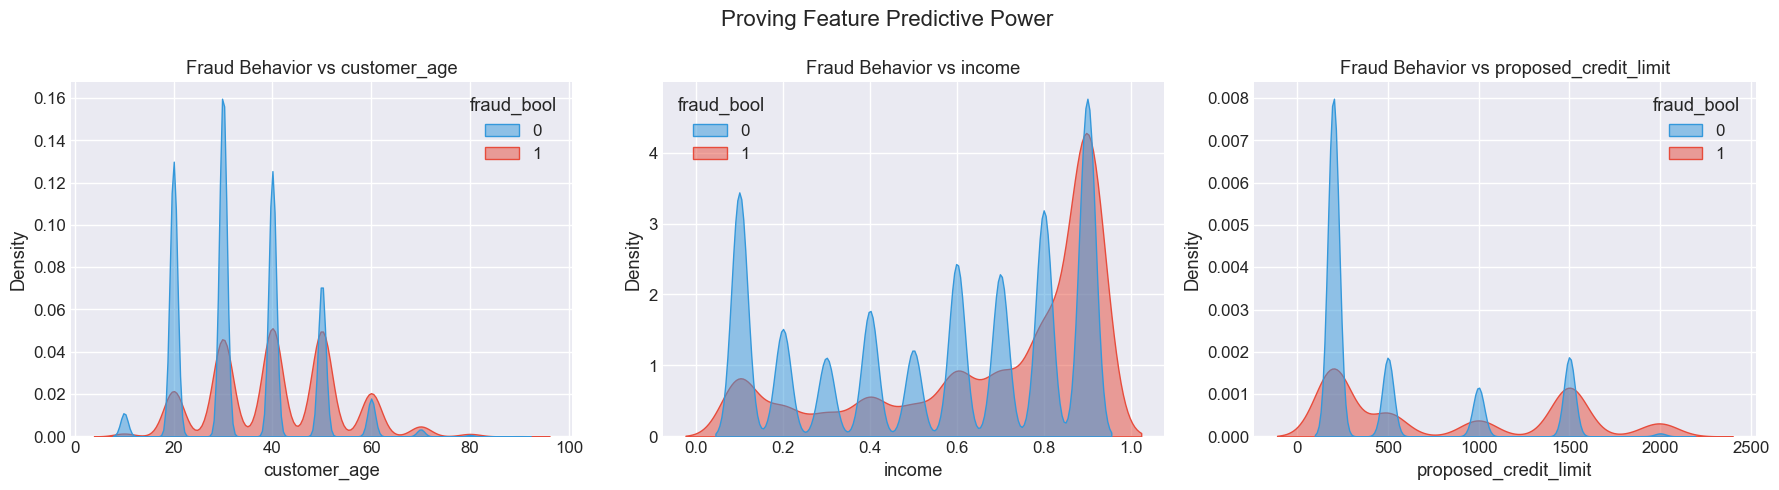


[ARCHITECTURAL NOTE]:
 - If the red (fraud) and blue (legitimate) curves overlap perfectly, the feature is weak.
 - If the red curve spikes in a different location than the blue curve, the feature is a strong predictor.


In [26]:
# Select a mix of financial and behavioral features
signal_cols = ['customer_age', 'income', 'proposed_credit_limit']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(signal_cols):
    # common_norm=False is critical here! It forces the tiny 1% fraud class 
    # to scale up visually so we can actually compare the curve shapes.
    sns.kdeplot(
        data=df, 
        x=feature, 
        hue='fraud_bool', 
        fill=True, 
        common_norm=False, 
        palette=['#3498db', '#e74c3c'], 
        alpha=0.5, 
        ax=axes[i]
    )
    axes[i].set_title(f'Fraud Behavior vs {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')

plt.suptitle("Proving Feature Predictive Power ", fontsize=16)
plt.tight_layout()
plt.show()

print("\n[ARCHITECTURAL NOTE]:")
print(" - If the red (fraud) and blue (legitimate) curves overlap perfectly, the feature is weak.")
print(" - If the red curve spikes in a different location than the blue curve, the feature is a strong predictor.")

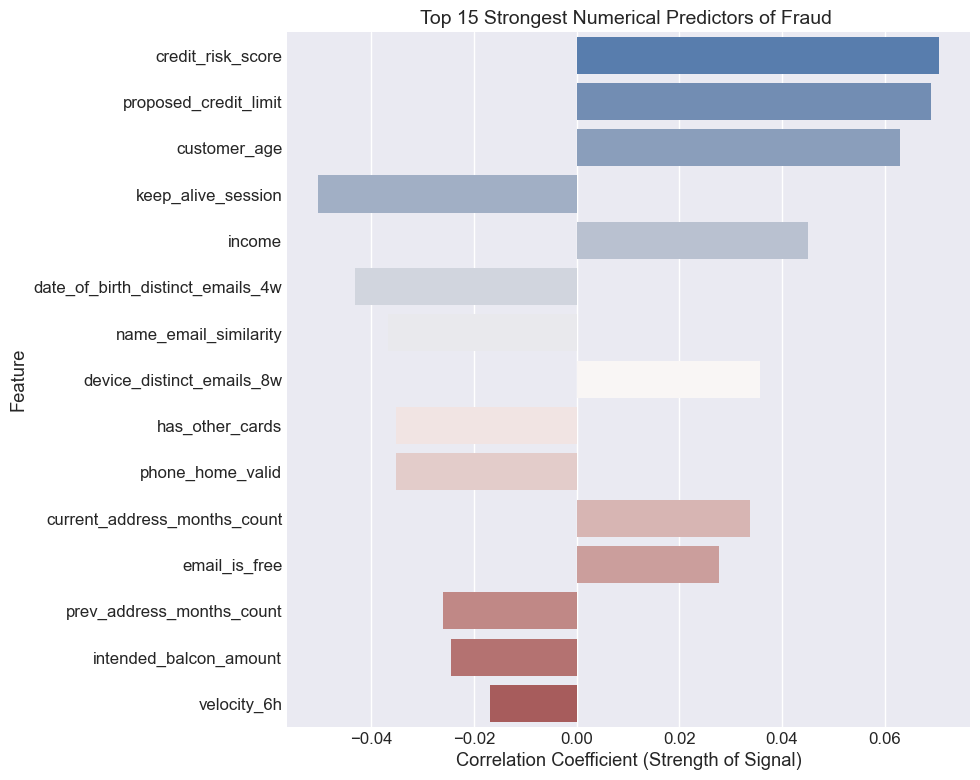


Fraud Rate breakdown for 'payment_type':
payment_type
AC    1.67%
AB    1.13%
AD    1.08%
AA    0.53%
AE    0.35%
Name: fraud_bool, dtype: object

Fraud Rate breakdown for 'employment_status':
employment_status
CC    2.47%
CG    1.55%
CA    1.22%
CB    0.69%
CD    0.38%
CE    0.23%
CF    0.19%
Name: fraud_bool, dtype: object

Fraud Rate breakdown for 'housing_status':
housing_status
BA    3.75%
BD    0.86%
BC    0.61%
BB     0.6%
BF    0.42%
BG     0.4%
BE    0.34%
Name: fraud_bool, dtype: object

Fraud Rate breakdown for 'source':
source
TELEAPP     1.59%
INTERNET     1.1%
Name: fraud_bool, dtype: object

Fraud Rate breakdown for 'device_os':
device_os
windows      2.47%
macintosh     1.4%
x11          1.12%
other        0.58%
linux        0.52%
Name: fraud_bool, dtype: object

[ARCHITECTURAL NOTE]: The numeric correlation chart dictates which features are most critical to preserve during PCA. The categorical fraud rates prove exactly why Target Encoding is mathematically superior to

In [28]:
# 1. NUMERICAL FEATURES: Correlation Ranking
# Select only numeric columns for correlation math
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate how strongly every numeric feature correlates with the target
correlations = numeric_df.corr()['fraud_bool'].drop('fraud_bool')

# We care about the absolute strength (both highly positive and highly negative signals)
top_numeric = correlations.abs().sort_values(ascending=False).head(15)
actual_correlations = correlations[top_numeric.index]

# Plot the Top 15 Strongest Signals
plt.figure(figsize=(10, 8))
# Use a divergent palette: Red for positive correlation (increases fraud risk), Blue for negative
sns.barplot(x=actual_correlations.values, y=actual_correlations.index, hue=actual_correlations.index, palette='vlag')
plt.title("Top 15 Strongest Numerical Predictors of Fraud ", fontsize=14)
plt.xlabel("Correlation Coefficient (Strength of Signal)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 2. CATEGORICAL FEATURES: Target Risk Mapping
# Select all text/categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    # Calculate the mean of fraud_bool (which equals the exact percentage of fraud)
    fraud_rates = df.groupby(col)['fraud_bool'].mean() * 100
    
    print(f"\nFraud Rate breakdown for '{col}':")
    # Sort from highest risk to lowest risk
    print(fraud_rates.sort_values(ascending=False).round(2).astype(str) + '%')

print("\n[ARCHITECTURAL NOTE]: The numeric correlation chart dictates which features are most critical to preserve during PCA. The categorical fraud rates prove exactly why Target Encoding is mathematically superior to One-Hot Encoding here.")

In [29]:
from sklearn.model_selection import train_test_split

# 1. Isolate the Target Variable
# We separate our features (X) from the answer key (y)
X = df.drop(columns=['fraud_bool'])
y = df['fraud_bool']

print(f"Pre-Split Matrix: {X.shape[0]:,} rows | {X.shape[1]} features")

# 2. The Stratified Split
# test_size=0.2 sets aside 200,000 rows for the final, untouched evaluation.
# stratify=y is the most important parameter here. It forces the split to maintain 
# the exact 99:1 legitimate-to-fraud ratio in both the train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 3. Deep Copying (The Engineering Fix)
# We create explicit copies in memory. If we don't do this, Pandas will throw 
# 'SettingWithCopyWarnings' during Phase 3 when we try to impute missing values.
X_train = X_train.copy()
X_test = X_test.copy()

# 4. Mathematical Verification
print("\n[VERIFICATION] Matrix Dimensions:")
print(f"  - Training Set: {X_train.shape[0]:,} rows")
print(f"  - Testing Set:  {X_test.shape[0]:,} rows")

print("\n[VERIFICATION] Target Stratification (Fraud Ratio):")
print(f"  - Global Dataset Fraud Rate: {(y.mean() * 100):.3f}%")
print(f"  - Training Set Fraud Rate:   {(y_train.mean() * 100):.3f}%")
print(f"  - Testing Set Fraud Rate:    {(y_test.mean() * 100):.3f}%")

print("\n[ARCHITECTURAL LOCK]: The test set is now permanently quarantined. Every median, skewness transform, and PCA component will be calculated STRICTLY using the Training Set.")

Pre-Split Matrix: 1,000,000 rows | 30 features

[VERIFICATION] Matrix Dimensions:
  - Training Set: 800,000 rows
  - Testing Set:  200,000 rows

[VERIFICATION] Target Stratification (Fraud Ratio):
  - Global Dataset Fraud Rate: 1.103%
  - Training Set Fraud Rate:   1.103%
  - Testing Set Fraud Rate:    1.103%

[ARCHITECTURAL LOCK]: The test set is now permanently quarantined. Every median, skewness transform, and PCA component will be calculated STRICTLY using the Training Set.


In [30]:
# Based directly on your Phase 1 EDA discoveries
sentinel_cols = [
    'prev_address_months_count', 
    'bank_months_count', 
    'current_address_months_count', 
    'session_length_in_minutes', 
    'credit_risk_score', 
    'device_distinct_emails_8w'
]

for col in sentinel_cols:
    if col in X_train.columns:
        # 1. Create the crucial behavioral flag
        X_train[f'{col}_is_missing'] = (X_train[col] == -1).astype(int)
        X_test[f'{col}_is_missing'] = (X_test[col] == -1).astype(int)
        
        # 2. Convert sentinels to true NaNs safely
        X_train[col] = X_train[col].replace(-1, np.nan)
        X_test[col] = X_test[col].replace(-1, np.nan)
        
        # 3. Calculate median STRICTLY from the training set
        train_median = X_train[col].median()
        
        # 4. Impute both sets
        X_train[col] = X_train[col].fillna(train_median)
        X_test[col] = X_test[col].fillna(train_median)
        print(f"  ✓ Processed '{col}': Imputed with training median ({train_median:.1f})")

  ✓ Processed 'prev_address_months_count': Imputed with training median (34.0)
  ✓ Processed 'bank_months_count': Imputed with training median (15.0)
  ✓ Processed 'current_address_months_count': Imputed with training median (53.0)
  ✓ Processed 'session_length_in_minutes': Imputed with training median (5.1)
  ✓ Processed 'credit_risk_score': Imputed with training median (122.0)
  ✓ Processed 'device_distinct_emails_8w': Imputed with training median (1.0)


In [31]:
# The exact list from your automated skewness scanner
highly_skewed_cols = [
    'days_since_request', 
    'prev_address_months_count', 
    'session_length_in_minutes', 
    'bank_branch_count_8w', 
    'intended_balcon_amount', 
    'device_distinct_emails_8w', 
    'zip_count_4w', 
    'current_address_months_count', 
    'proposed_credit_limit'
]

for col in highly_skewed_cols:
    if col in X_train.columns:
        # Apply Signed Pseudo-Log: y = sign(x) * log(1 + |x|)
        # This safely handles heavy right tails AND the negative overdraft balances
        X_train[f'{col}_log'] = np.sign(X_train[col]) * np.log1p(np.abs(X_train[col]))
        X_test[f'{col}_log'] = np.sign(X_test[col]) * np.log1p(np.abs(X_test[col]))
        
        # Drop the raw columns to prevent multicollinearity (duplicate signals)
        X_train = X_train.drop(columns=[col])
        X_test = X_test.drop(columns=[col])
        print(f"  ✓ Applied Pseudo-Log to '{col}' and dropped raw feature.")

print(f"Current Training Matrix Shape: {X_train.shape[0]:,} rows | {X_train.shape[1]} features")

  ✓ Applied Pseudo-Log to 'days_since_request' and dropped raw feature.
  ✓ Applied Pseudo-Log to 'prev_address_months_count' and dropped raw feature.
  ✓ Applied Pseudo-Log to 'session_length_in_minutes' and dropped raw feature.
  ✓ Applied Pseudo-Log to 'bank_branch_count_8w' and dropped raw feature.
  ✓ Applied Pseudo-Log to 'intended_balcon_amount' and dropped raw feature.
  ✓ Applied Pseudo-Log to 'device_distinct_emails_8w' and dropped raw feature.
  ✓ Applied Pseudo-Log to 'zip_count_4w' and dropped raw feature.
  ✓ Applied Pseudo-Log to 'current_address_months_count' and dropped raw feature.
  ✓ Applied Pseudo-Log to 'proposed_credit_limit' and dropped raw feature.
Current Training Matrix Shape: 800,000 rows | 36 features


In [32]:
from sklearn.preprocessing import StandardScaler, TargetEncoder
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Domain Feature Engineering
def engineer_domain_features(df_features):
    df_out = df_features.copy()
    
    # 1. Credit Utilization Proxy
    # We use the log-transformed versions we created in Phase 3. 
    # Adding a tiny constant (0.001) prevents division by zero.
    if 'intended_balcon_amount_log' in df_out.columns and 'proposed_credit_limit_log' in df_out.columns:
        df_out['credit_utilization_proxy'] = df_out['intended_balcon_amount_log'] / (df_out['proposed_credit_limit_log'] + 0.001)
        print("  ✓ Engineered 'credit_utilization_proxy'")
    
    # 2. Suspicious Identity Velocity
    # High email velocity + Low name match = Highly suspicious synthetic identity
    if 'device_distinct_emails_8w_log' in df_out.columns and 'name_email_similarity' in df_out.columns:
        df_out['suspicious_identity_velocity'] = (df_out['device_distinct_emails_8w_log'] + 1) / (df_out['name_email_similarity'] + 0.001)
        
        # We drop the raw velocity column since its signal is now mathematically absorbed
        df_out = df_out.drop(columns=['device_distinct_emails_8w_log'])
        print("  ✓ Engineered 'suspicious_identity_velocity' and dropped raw feature.")
        
    return df_out

X_train = engineer_domain_features(X_train)
X_test = engineer_domain_features(X_test)

  ✓ Engineered 'credit_utilization_proxy'
  ✓ Engineered 'suspicious_identity_velocity' and dropped raw feature.
  ✓ Engineered 'credit_utilization_proxy'
  ✓ Engineered 'suspicious_identity_velocity' and dropped raw feature.


In [33]:
# Target Encoding
print("\n[Executing Step 4.2: Target Encoding Categoricals]")
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

if cat_cols:
    print(f"  Mapping {len(cat_cols)} text columns to historical fraud probabilities...")
    # smooth='auto' helps prevent overfitting on categories with very few samples
    encoder = TargetEncoder(smooth='auto')
    
    # CRITICAL: We fit STRICTLY on the training labels to prevent target leakage
    X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols], y_train)
    X_test[cat_cols] = encoder.transform(X_test[cat_cols])
    print(f"  ✓ Target Encoding complete. Text columns converted to dense floats.")



[Executing Step 4.2: Target Encoding Categoricals]
  Mapping 5 text columns to historical fraud probabilities...
  ✓ Target Encoding complete. Text columns converted to dense floats.


In [34]:
# Standard Scaling

scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

# PRO TIP: Convert the output NumPy arrays back into Pandas DataFrames.
# This preserves the column names, which is invaluable if you need to 
# debug feature importance or PCA component weights later!
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X_test.columns, index=X_test.index)

print("Scaling complete (Mean = 0, Variance = 1).")

print(f"Final Pre-PCA Training Matrix: {X_train_scaled.shape[0]:,} rows | {X_train_scaled.shape[1]} highly dense features")

Scaling complete (Mean = 0, Variance = 1).
Final Pre-PCA Training Matrix: 800,000 rows | 37 highly dense features


Total Original Features: 37
Components required for 95% variance: 30


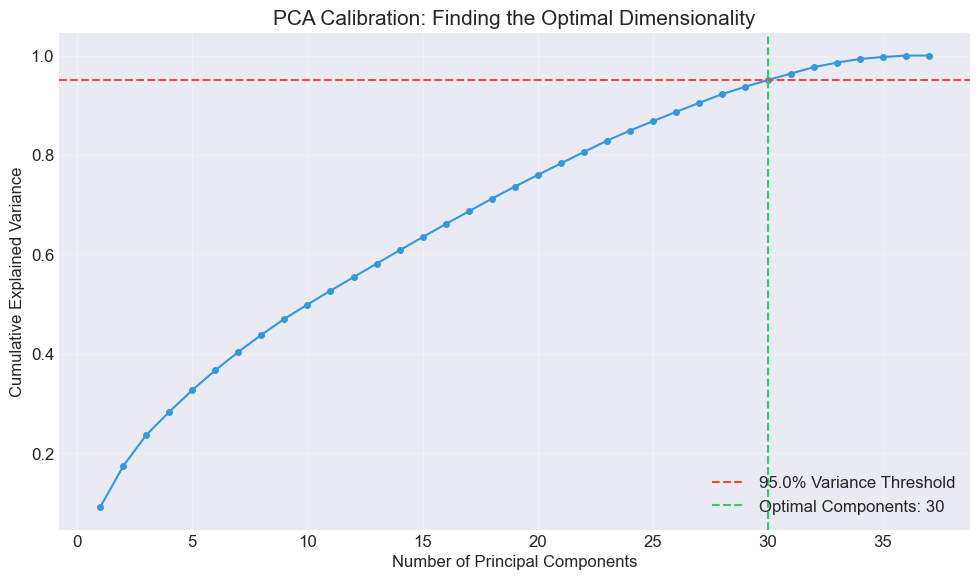


[ARCHITECTURAL NOTE]: The curve flattening out proves that the last few features were mostly overlapping noise or multicollinearity.


In [35]:
from sklearn.decomposition import PCA

# 1. Fit an unconstrained PCA strictly on the training data
# We don't specify n_components yet, so it calculates all of them.
pca_tuner = PCA(random_state=42)
pca_tuner.fit(X_train_scaled)

# 2. Calculate Cumulative Explained Variance
cumulative_variance = np.cumsum(pca_tuner.explained_variance_ratio_)

# 3. Mathematically locate the 95% threshold
target_variance = 0.95
# np.argmax finds the first index where the condition is True. We add 1 because indices start at 0.
optimal_components = np.argmax(cumulative_variance >= target_variance) + 1

print(f"Total Original Features: {X_train_scaled.shape[1]}")
print(f"Components required for 95% variance: {optimal_components}")

# 4. Plot the Elbow Curve to visualize the drop-off 
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         marker='o', linestyle='-', markersize=4, color='#3498db')

# Draw the threshold lines
plt.axhline(y=target_variance, color='#e74c3c', linestyle='--', 
            label=f'{target_variance*100}% Variance Threshold')
plt.axvline(x=optimal_components, color='#2ecc71', linestyle='--', 
            label=f'Optimal Components: {optimal_components}')

plt.title('PCA Calibration: Finding the Optimal Dimensionality', fontsize=15)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n[ARCHITECTURAL NOTE]: The curve flattening out proves that the last few features were mostly overlapping noise or multicollinearity.")

In [36]:
# 1. Initialize the final PCA with our mathematically proven threshold
pca_final = PCA(n_components=optimal_components, random_state=42)

# 2. Transform the Training Set (Fit AND Transform)
X_train_pca_array = pca_final.fit_transform(X_train_scaled)

# 3. Transform the Testing Set (Transform ONLY, using the training mapping)
X_test_pca_array = pca_final.transform(X_test_scaled)

# 4. Wrap the outputs back into Pandas DataFrames for clean handling in Phase 6
# We generate new column names (PC1, PC2, PC3...) since the original features are now blended
pc_columns = [f"PC{i}" for i in range(1, optimal_components + 1)]

X_train_pca = pd.DataFrame(X_train_pca_array, columns=pc_columns, index=X_train_scaled.index)
X_test_pca = pd.DataFrame(X_test_pca_array, columns=pc_columns, index=X_test_scaled.index)

print(f"Original Training Shape:  {X_train_scaled.shape}")
print(f"Compressed Training Shape: {X_train_pca.shape}")
print("\nMatrix successfully compressed into dense, orthogonal vectors.")

Original Training Shape:  (800000, 37)
Compressed Training Shape: (800000, 30)

Matrix successfully compressed into dense, orthogonal vectors.


Training validation model to audit feature importance... (takes ~15-30 seconds)


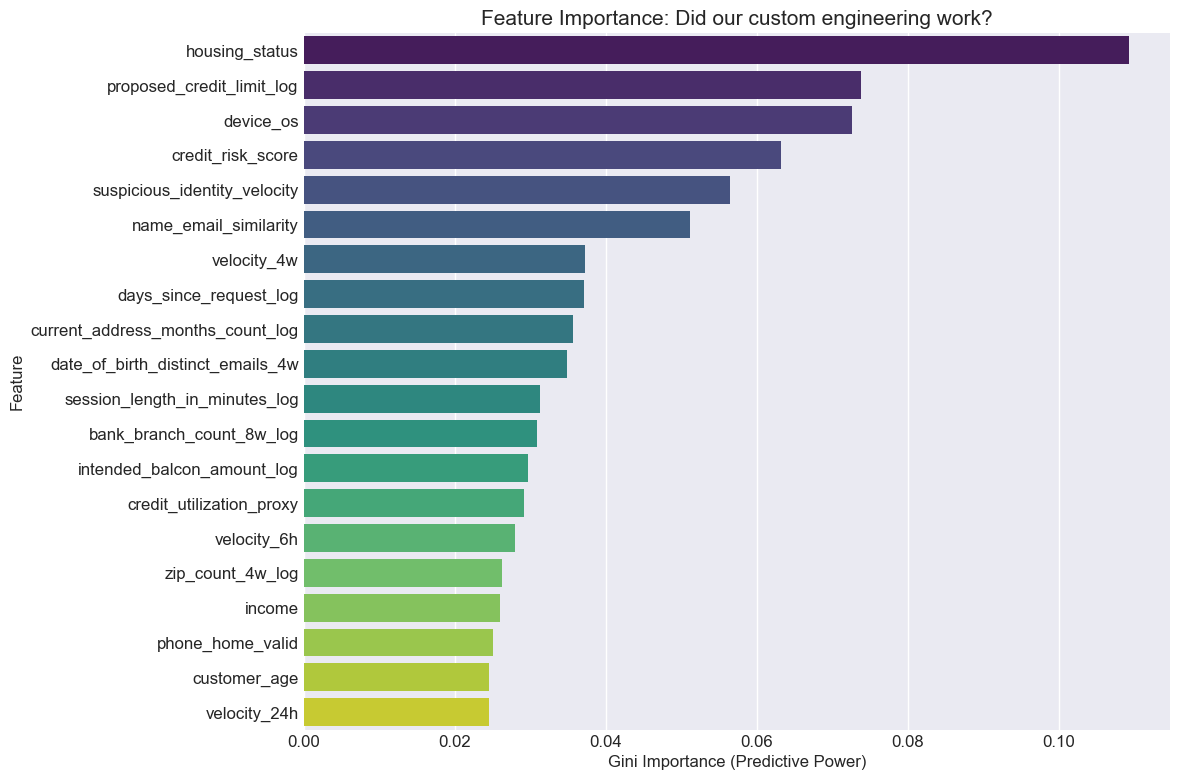


[HOW TO READ THIS CHART]:
Scan the top 10 bars. Do you see 'credit_utilization_proxy', any '_is_missing' flags, or your '_log' transformed features?
If yes, your feature engineering successfully captured massive predictive signals that the raw data completely missed.


In [38]:
from sklearn.ensemble import RandomForestClassifier

# We train a fast Random Forest on the PRE-PCA scaled data to see what it values
# We use a small number of trees (n_estimators=50) just to get a quick importance ranking
rf_proof = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

print("Training validation model to audit feature importance... (takes ~15-30 seconds)")
rf_proof.fit(X_train_scaled, y_train)

# Extract and sort the feature importances
importances = pd.Series(rf_proof.feature_importances_, index=X_train_scaled.columns)
top_20_features = importances.sort_values(ascending=False).head(20)

# Plot the definitive proof
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_features.values, y=top_20_features.index, palette='viridis')
plt.title("Feature Importance: Did our custom engineering work?", fontsize=15)
plt.xlabel("Gini Importance (Predictive Power)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

print("\n[HOW TO READ THIS CHART]:")
print("Scan the top 10 bars. Do you see 'credit_utilization_proxy', any '_is_missing' flags, or your '_log' transformed features?")
print("If yes, your feature engineering successfully captured massive predictive signals that the raw data completely missed.")

In [39]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Initialize SMOTE
# sampling_strategy=0.25 means we will synthesize new fraud data 
# until the fraud class is exactly 25% the size of the legitimate class.
smote = SMOTE(sampling_strategy=0.25, random_state=42)

print(f"Pre-SMOTE Training Imbalance: \n{y_train.value_counts(normalize=True) * 100}")
print("\nApplying SMOTE strictly to the compressed training matrix... (This may take a minute)")

# 2. Resample ONLY the training data
X_train_final, y_train_final = smote.fit_resample(X_train_pca, y_train)

# 3. The test set remains completely untouched
X_test_final = X_test_pca
y_test_final = y_test

print(f"Final Optimized Training Matrix: {X_train_final.shape[0]:,} rows | {X_train_final.shape[1]} features")
print(f"Post-SMOTE Training Distribution: \n{y_train_final.value_counts(normalize=True) * 100}")
print(f"Final Untouched Testing Matrix:  {X_test_final.shape[0]:,} rows | {X_test_final.shape[1]} features")

Pre-SMOTE Training Imbalance: 
fraud_bool
0    98.897125
1     1.102875
Name: proportion, dtype: float64

Applying SMOTE strictly to the compressed training matrix... (This may take a minute)
Final Optimized Training Matrix: 988,971 rows | 30 features
Post-SMOTE Training Distribution: 
fraud_bool
0    80.00002
1    19.99998
Name: proportion, dtype: float64
Final Untouched Testing Matrix:  200,000 rows | 30 features


In [44]:
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

# 1. Apply our hard-won mathematical threshold (30 components)
pca_final = PCA(n_components=30)

# Fit and transform ONLY on the scaled training data
X_train_pca = pca_final.fit_transform(X_train_scaled)

# Transform the test data using the mapping learned from the training data
X_test_pca = pca_final.transform(X_test_scaled)

print(f"Original Training Shape: {X_train_scaled.shape}")
print(f"PCA Reduced Training Shape: {X_train_pca.shape}")

# 2. Balance the dataset using SMOTE
# sampling_strategy=0.25 boosts the minority class (Fraud) to exactly 25% the size of the majority class
print("\nApplying SMOTE to minority class (Fraud) in the training set...")
smote = SMOTE(sampling_strategy=0.25, random_state=42)

# Fit and resample ONLY the training data to prevent Data Leakage
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pca, y_train)

# 3. Verify the new distribution
print("\nClass Distribution After SMOTE (Targeting 80/20 split):")
print(y_train_resampled.value_counts(normalize=True) * 100)

print(f"\nFinal Resampled Training Matrix Shape: {X_train_resampled.shape}")

Original Training Shape: (800000, 35)
PCA Reduced Training Shape: (800000, 30)

Applying SMOTE to minority class (Fraud) in the training set...

Class Distribution After SMOTE (Targeting 80/20 split):
fraud_bool
0    80.00002
1    19.99998
Name: proportion, dtype: float64

Final Resampled Training Matrix Shape: (988971, 30)


--- A/B TEST: RAW BASELINE VS. OPTIMIZED PIPELINE ---
Training Baseline Model on 50 raw features...
Training Optimized Model on 30 PCA components + SMOTE...


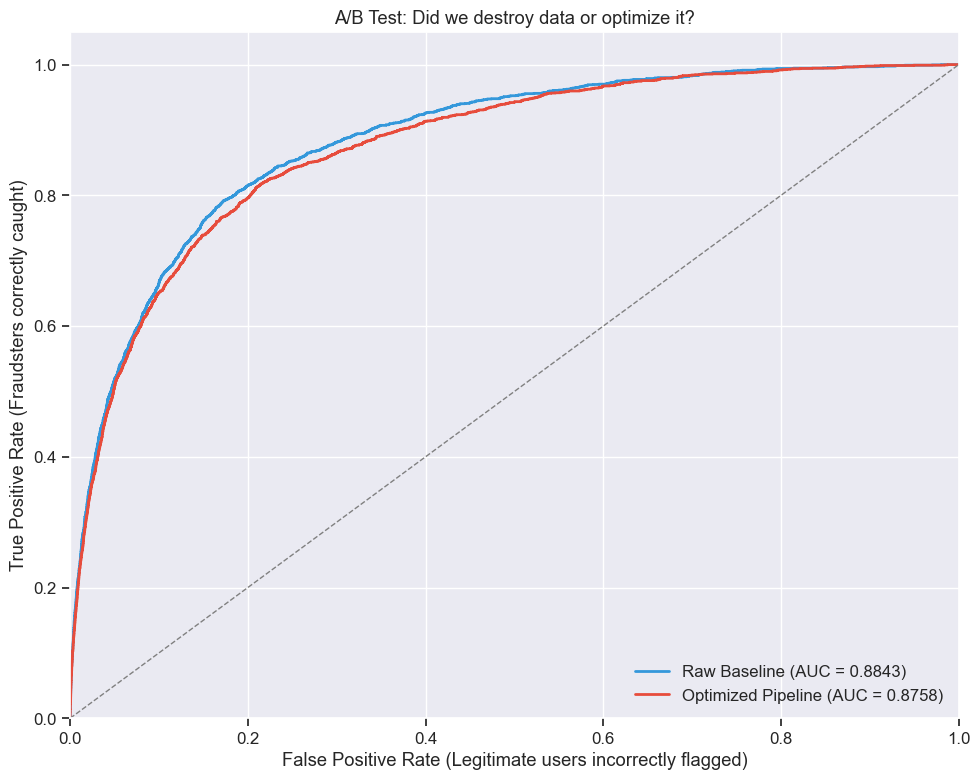


--- FINAL RESULTS ---
Baseline AUC:  0.8843
Optimized AUC: 0.8758


In [45]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("--- A/B TEST: RAW BASELINE VS. OPTIMIZED PIPELINE ---")

# ==========================================
# 1. PREP THE BASELINE (Raw Data)
# ==========================================
df_baseline = df_clean.copy()

# Apply basic One-Hot Encoding just so the baseline model can read the text
categorical_cols_base = df_baseline.select_dtypes(include=['object']).columns
df_baseline = pd.get_dummies(df_baseline, columns=categorical_cols_base, drop_first=True)

X_base = df_baseline.drop(columns=['fraud_bool'])
y_base = df_baseline['fraud_bool']

# Split and scale the baseline
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42, stratify=y_base
)
scaler_base = StandardScaler()
X_train_base_scaled = scaler_base.fit_transform(X_train_base)
X_test_base_scaled = scaler_base.transform(X_test_base)

# Train Baseline Model
print(f"Training Baseline Model on {X_train_base_scaled.shape[1]} raw features...")
# We use class_weight='balanced' here because this raw data doesn't have SMOTE
lr_base = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_base.fit(X_train_base_scaled, y_train_base)
y_pred_prob_base = lr_base.predict_proba(X_test_base_scaled)[:, 1]


# ==========================================
# 2. PREP THE OPTIMIZED PIPELINE
# ==========================================
print("Training Optimized Model on 30 PCA components + SMOTE...")
lr_opt = LogisticRegression(max_iter=1000)
# No class_weight needed here because our SMOTE algorithm already balanced the training data!
lr_opt.fit(X_train_resampled, y_train_resampled)

# Predict on our pure, untouched PCA test set
y_pred_prob_opt = lr_opt.predict_proba(X_test_pca)[:, 1]


# ==========================================
# 3. CALCULATE METRICS & PLOT
# ==========================================
fpr_base, tpr_base, _ = roc_curve(y_test_base, y_pred_prob_base)
roc_auc_base = auc(fpr_base, tpr_base)

fpr_opt, tpr_opt, _ = roc_curve(y_test, y_pred_prob_opt)
roc_auc_opt = auc(fpr_opt, tpr_opt)

# Plotting the A/B Test
plt.figure(figsize=(10, 8))
plt.plot(fpr_base, tpr_base, color='#3498db', lw=2, label=f'Raw Baseline (AUC = {roc_auc_base:.4f})')
plt.plot(fpr_opt, tpr_opt, color='#e74c3c', lw=2, label=f'Optimized Pipeline (AUC = {roc_auc_opt:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Legitimate users incorrectly flagged)')
plt.ylabel('True Positive Rate (Fraudsters correctly caught)')
plt.title('A/B Test: Did we destroy data or optimize it?')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("\n--- FINAL RESULTS ---")
print(f"Baseline AUC:  {roc_auc_base:.4f}")
print(f"Optimized AUC: {roc_auc_opt:.4f}")

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization style
plt.style.use('seaborn-v0_8-darkgrid')

print("--- EDA PART 1: VARIANCE & CARDINALITY CHECK ---")
df_eda = pd.read_csv("../data/Base.csv")

# Calculate the number of unique values for every single column
unique_counts = df_eda.nunique()

# 1. Hunt for Zero Variance (Exactly 1 unique value)
zero_variance_cols = unique_counts[unique_counts == 1].index.tolist()

print(f"Total columns scanned: {len(df_eda.columns)}")
if len(zero_variance_cols) > 0:
    print(f"CRITICAL WARNING: Found {len(zero_variance_cols)} columns with ZERO variance:")
    for col in zero_variance_cols:
        val = df_eda[col].iloc[0]
        print(f"  - '{col}' (Every single row contains the exact value: {val})")
else:
    print("No zero variance columns found.")

# 2. Check for High Cardinality Categoricals (Too many unique text values)
categorical_cols = df_eda.select_dtypes(include=['object']).columns
print("\nCategorical Column Cardinality (Unique Text Values):")
for col in categorical_cols:
    print(f"  - {col}: {df_eda[col].nunique()} unique categories")

--- EDA PART 1: VARIANCE & CARDINALITY CHECK ---
Total columns scanned: 32
CRITICAL WARNING: Found 1 columns with ZERO variance:
  - 'device_fraud_count' (Every single row contains the exact value: 0)

Categorical Column Cardinality (Unique Text Values):
  - payment_type: 5 unique categories
  - employment_status: 7 unique categories
  - housing_status: 7 unique categories
  - source: 2 unique categories
  - device_os: 5 unique categories


--- EDA PART 2: HIDDEN SENTINEL DETECTIVE ---
Columns containing the hidden missing value (-1):
  - prev_address_months_count: 712,920 rows (71.29%)
  - bank_months_count: 253,635 rows (25.36%)
  - current_address_months_count: 4,254 rows (0.43%)
  - session_length_in_minutes: 2,015 rows (0.20%)
  - credit_risk_score: 488 rows (0.05%)
  - device_distinct_emails_8w: 359 rows (0.04%)


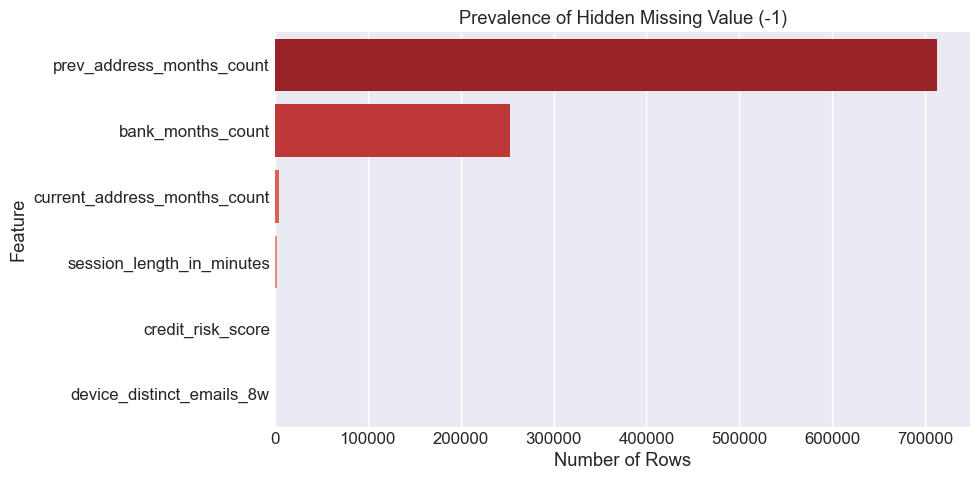

In [15]:
print("--- EDA PART 2: HIDDEN SENTINEL DETECTIVE ---")

# We suspect -1 is used as a "missing" flag. Let's see exactly how widespread it is.
sentinel_value = -1
sentinel_counts = (df_eda == sentinel_value).sum()

# Filter only columns that actually contain the sentinel value
columns_with_sentinels = sentinel_counts[sentinel_counts > 0].sort_values(ascending=False)

print(f"Columns containing the hidden missing value ({sentinel_value}):")
if len(columns_with_sentinels) > 0:
    for col, count in columns_with_sentinels.items():
        percentage = (count / len(df_eda)) * 100
        print(f"  - {col}: {count:,} rows ({percentage:.2f}%)")
else:
    print(f"No {sentinel_value} values found.")
    
# Plot the sentinel distribution 
if len(columns_with_sentinels) > 0:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=columns_with_sentinels.values, y=columns_with_sentinels.index, hue = columns_with_sentinels.index, palette='Reds_r')
    plt.title(f"Prevalence of Hidden Missing Value ({sentinel_value})")
    plt.xlabel("Number of Rows")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

--- EDA PART 3: FRAUD BEHAVIOR VISUALIZATION ---


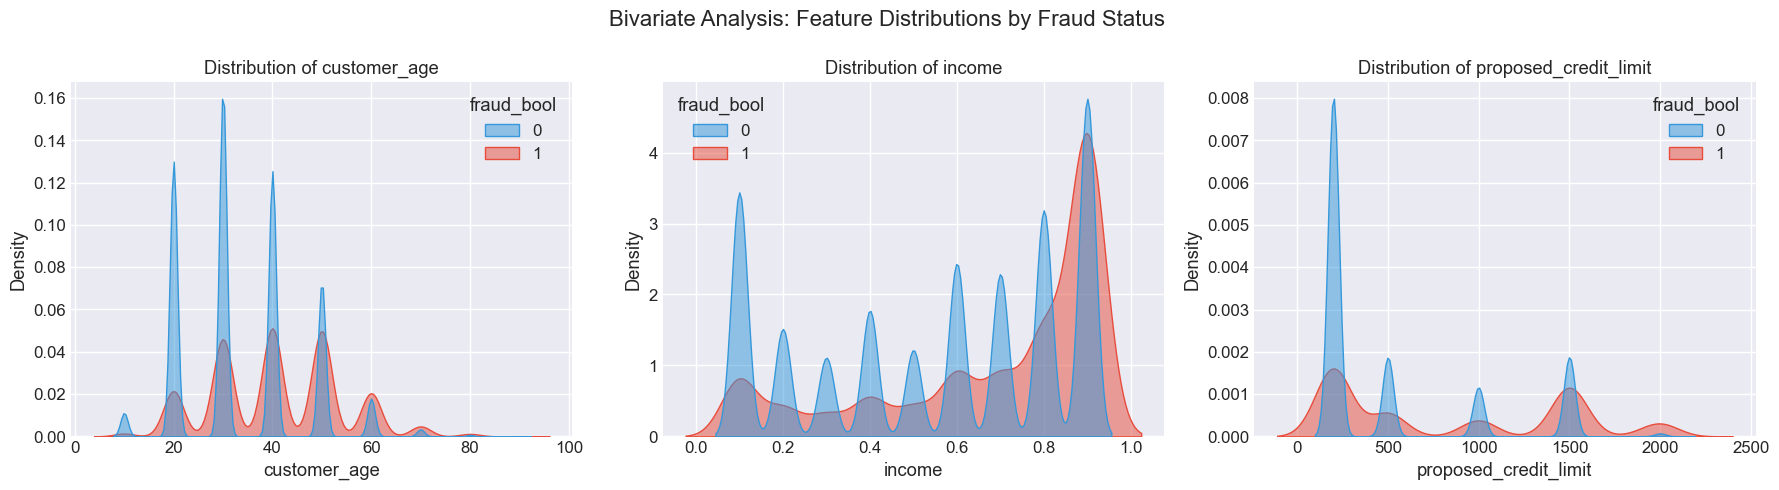

In [16]:
print("--- EDA PART 3: FRAUD BEHAVIOR VISUALIZATION ---")

# Let's look at how the 'customer_age' and 'income' distributions change for fraudsters
features_to_plot = ['customer_age', 'income', 'proposed_credit_limit']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(features_to_plot):
    # We use KDE (Kernel Density Estimate) to smooth the distribution curve
    sns.kdeplot(
        data=df_eda, 
        x=feature, 
        hue='fraud_bool', 
        fill=True, 
        common_norm=False, # Scales the 1% fraud class up so we can actually see it
        palette=['#3498db', '#e74c3c'], 
        alpha=0.5, 
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')

plt.suptitle("Bivariate Analysis: Feature Distributions by Fraud Status ", fontsize=16)
plt.tight_layout()
plt.show()